# Capacity-based risk workflow

This notebook follows a complete risk workflow: define losses and scenarios, build an empirical distribution, choose a capacity and a distortion, estimate and interpret risk, produce conditional and rolling forecasts, and backtest the resulting capital series. Larger values always represent larger losses.

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from capacities_ml.capacities import is_concave_capacity, validate_capacity
from capacities_ml.risk import (
    DistortedCapacity,
    DistortionRiskMeasure,
    EmpiricalLossDistribution,
    ExpectedShortfallDistortion,
    KusuokaRiskMeasure,
    ProbabilityCapacity,
    ProportionalHazardsDistortion,
    ResidualBootstrapDistribution,
    SpectralRiskMeasure,
    UpperEnvelopeCapacity,
    ValueAtRiskDistortion,
    block_bootstrap_interval,
    capital_backtest,
    check_risk_measure_axioms,
    choquet_risk_measure,
    christoffersen_independence_test,
    diversification_benefit,
    distortion_risk_measure,
    exceedance_indicator,
    expected_shortfall,
    generalized_tail_value_at_risk,
    generalized_value_at_risk,
    hac_mean_interval,
    kupiec_coverage_test,
    risk_contributions,
    rolling_risk_estimates,
    stress_backtest,
    validate_distortion,
    value_at_risk,
)

pd.options.display.float_format = "{:.4f}".format
rng = np.random.default_rng(42)

## 1. Loss data and chronological split

The example uses two correlated asset-loss series. A high-volatility interval represents a crisis. The first part of the sample is used for initial estimation and the final part for forecast evaluation.

,count,mean,std,min,25%,50%,75%,max
asset_a,520.0000,-0.1034,1.2905,-7.3842,-0.7245,-0.1010,0.5695,6.8352
asset_b,520.0000,0.0766,1.2836,-5.7991,-0.6214,0.0467,0.7641,6.7401
portfolio,520.0000,-0.0314,1.1223,-5.9082,-0.6284,-0.0429,0.5149,6.7972


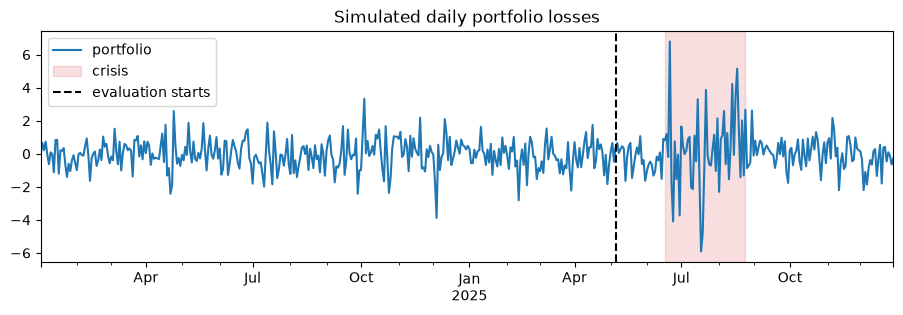

In [2]:
n_observations = 520
dates = pd.bdate_range("2024-01-02", periods=n_observations)
crisis = np.zeros(n_observations, dtype=bool)
crisis[380:430] = True
volatility_scale = np.where(crisis, 2.4, 1.0)

common_shock = rng.standard_t(df=5, size=n_observations) / np.sqrt(5 / 3)
asset_a_shock = rng.normal(size=n_observations)
asset_b_shock = rng.normal(size=n_observations)
asset_a = np.zeros(n_observations)
asset_b = np.zeros(n_observations)
for position in range(1, n_observations):
    asset_a[position] = (
        0.12 * asset_a[position - 1]
        + volatility_scale[position]
        * (0.80 * common_shock[position] + 0.60 * asset_a_shock[position])
    )
    asset_b[position] = (
        0.08 * asset_b[position - 1]
        + volatility_scale[position]
        * (0.55 * common_shock[position] + 0.84 * asset_b_shock[position])
    )

loss_data = pd.DataFrame(
    {"asset_a": asset_a, "asset_b": asset_b},
    index=dates,
)
loss_data["portfolio"] = 0.60 * loss_data["asset_a"] + 0.40 * loss_data["asset_b"]
split_position = 350
train_losses = loss_data["portfolio"].iloc[:split_position]
test_losses = loss_data["portfolio"].iloc[split_position:]

display(loss_data.describe().T)
loss_data["portfolio"].plot(figsize=(11, 3), title="Simulated daily portfolio losses")
plt.axvspan(dates[380], dates[429], color="tab:red", alpha=0.15, label="crisis")
plt.axvline(dates[split_position], color="black", linestyle="--", label="evaluation starts")
plt.legend()
plt.show()

## 2. Empirical distribution and scenario weights

A `ProbabilityCapacity` assigns a probability to every event by adding its scenario weights. Here, estimation uses the most recent 256 training observations as an equally weighted historical window. The empirical distribution then evaluates survival probabilities and quantiles through that capacity.

In [3]:
calibration_window = 256
recency_weights = np.zeros(train_losses.size)
recency_weights[-calibration_window:] = 1.0 / calibration_window
base_capacity = ProbabilityCapacity(recency_weights)
distribution = EmpiricalLossDistribution(train_losses, capacity=base_capacity)
alpha = 0.95

distribution_summary = pd.Series(
    {
        "weighted mean loss": np.average(train_losses, weights=recency_weights),
        "P(loss > 1)": distribution.survival(1.0),
        "lower VaR 95%": distribution.lower_quantile(alpha),
        "upper VaR 95%": distribution.upper_quantile(alpha),
    },
    name="estimate",
)
display(distribution_summary.to_frame())

,estimate
weighted mean loss,-0.0648
P(loss > 1),0.1250
lower VaR 95%,1.4608
upper VaR 95%,1.4608


## 3. Distortion and capacity validation

A distortion changes the weight assigned to tail events. Expected Shortfall uses a concave distortion, so composing it with a probability capacity produces a concave capacity. Exact capacity validation enumerates all events and is therefore demonstrated on eight scenarios; large operational samples use capacity classes whose construction already guarantees validity.

In [4]:
es_distortion = ExpectedShortfallDistortion(alpha)
validate_distortion(es_distortion)

small_base_capacity = ProbabilityCapacity(np.ones(8))
small_risk_capacity = DistortedCapacity(small_base_capacity, es_distortion)
validate_capacity(small_risk_capacity, max_elements=8)

print("Distortion is concave:", es_distortion.is_concave())
print("Distorted capacity is concave:", is_concave_capacity(small_risk_capacity))
print("Exact capacity validation: passed")

Distortion is concave: True
Distorted capacity is concave: True
Exact capacity validation: passed


## 4. Point estimation and Choquet decomposition

The distortion risk measure is the Choquet integral under the distorted scenario capacity. `risk_contributions` shows how ordered loss increments and tail-event capacities build the final value.

In [5]:
risk_capacity = DistortedCapacity(base_capacity, es_distortion)
point_estimates = pd.Series(
    {
        "weighted VaR 95%": value_at_risk(
            train_losses, alpha, sample_weight=recency_weights
        ),
        "weighted ES 95%": expected_shortfall(
            train_losses, alpha, sample_weight=recency_weights
        ),
        "distortion form of ES": distortion_risk_measure(
            train_losses, es_distortion, capacity=base_capacity
        ),
        "Choquet form of ES": choquet_risk_measure(train_losses, risk_capacity),
        "proportional-hazards risk": distortion_risk_measure(
            train_losses, ProportionalHazardsDistortion(0.70), capacity=base_capacity
        ),
    },
    name="risk",
)
display(point_estimates.to_frame())

contributions = risk_contributions(train_losses, risk_capacity)
display(contributions.tail(10))
print("Sum of contributions:", contributions["contribution"].sum())

,risk
weighted VaR 95%,1.4608
weighted ES 95%,1.8528
distortion form of ES,1.8528
Choquet form of ES,1.8528
proportional-hazards risk,0.2516


,loss,increment,capacity,contribution
340,1.6731,0.0019,0.5469,0.0010
341,1.7530,0.0800,0.4687,0.0375
342,1.7570,0.0039,0.3906,0.0015
343,1.8551,0.0981,0.3906,0.0383
344,1.8671,0.0120,0.3125,0.0038
345,1.8811,0.0140,0.3125,0.0044
346,2.0996,0.2185,0.2344,0.0512
347,2.1841,0.0845,0.1562,0.0132
348,2.5865,0.4024,0.0781,0.0314
349,3.3277,0.7412,0.0781,0.0579


Sum of contributions: 1.8528060943815277


## 5. Ambiguity, generalized quantiles, and spectral measures

An upper envelope represents ambiguity across several plausible scenario probabilities. Generalized VaR and Tail-VaR use that non-additive event capacity. Spectral and Kusuoka objects combine several confidence levels into reusable risk measures.

In [6]:
short_window_weights = np.zeros(train_losses.size)
short_window_weights[-128:] = 1.0 / 128.0
ambiguity_capacity = UpperEnvelopeCapacity(
    np.vstack([recency_weights, short_window_weights])
)
spectral_measure = SpectralRiskMeasure(
    levels=(0.90, 0.95, 0.99),
    weights=(0.20, 0.50, 0.30),
    quantile="lower",
)
kusuoka_measure = KusuokaRiskMeasure(
    levels=(0.90, 0.95),
    weights=(0.40, 0.60),
    worst_case_weight=0.10,
)

ambiguity_estimates = pd.Series(
    {
        "generalized VaR 95%": generalized_value_at_risk(
            train_losses, alpha, ambiguity_capacity
        ),
        "generalized Tail-VaR 95%": generalized_tail_value_at_risk(
            train_losses, alpha, ambiguity_capacity
        ),
        "spectral risk": spectral_measure(
            train_losses, capacity=ambiguity_capacity
        ),
        "Kusuoka risk": kusuoka_measure(
            train_losses, capacity=ambiguity_capacity
        ),
    },
    name="risk",
)
display(ambiguity_estimates.to_frame())

,risk
generalized VaR 95%,1.4608
generalized Tail-VaR 95%,1.8699
spectral risk,1.5681
Kusuoka risk,1.8949


## 6. Conditional loss distributions

A point regressor estimates the conditional location from information available at the previous date. Bootstrapped training residuals then become conditional loss scenarios, on which the same VaR and ES functions can be applied.

In [7]:
conditional_frame = pd.DataFrame(
    {
        "lagged_loss": loss_data["portfolio"].shift(1),
        "lagged_absolute_loss": loss_data["portfolio"].abs().shift(1),
        "loss": loss_data["portfolio"],
    }
).dropna()
X_conditional = conditional_frame[["lagged_loss", "lagged_absolute_loss"]]
y_conditional = conditional_frame["loss"]
conditional_train = split_position - 1
conditional_model = ResidualBootstrapDistribution(
    LinearRegression(),
    max_scenarios=256,
    random_state=9,
).fit(
    X_conditional.iloc[:conditional_train],
    y_conditional.iloc[:conditional_train],
)

forecast_rows = X_conditional.iloc[conditional_train : conditional_train + 5]
conditional_distributions = conditional_model.predict_distribution(forecast_rows)
conditional_forecasts = pd.DataFrame(
    {
        "observed_loss": y_conditional.loc[forecast_rows.index],
        "conditional_VaR_95": [
            value_at_risk(distribution.losses, alpha)
            for distribution in conditional_distributions
        ],
        "conditional_ES_95": [
            expected_shortfall(distribution.losses, alpha)
            for distribution in conditional_distributions
        ],
    },
    index=forecast_rows.index,
)
display(conditional_forecasts)

,observed_loss,conditional_VaR_95,conditional_ES_95
2025-05-06,0.3877,1.1952,1.5956
2025-05-07,0.6566,1.3075,1.7079
2025-05-08,0.0488,1.3248,1.7252
2025-05-09,0.2775,1.2857,1.6861
2025-05-12,0.4569,1.3004,1.7009


## 7. One-step-ahead rolling capital

Each capital value uses only losses strictly before its forecast date. The same rolling window produces VaR for coverage testing and ES for tail-capital assessment.

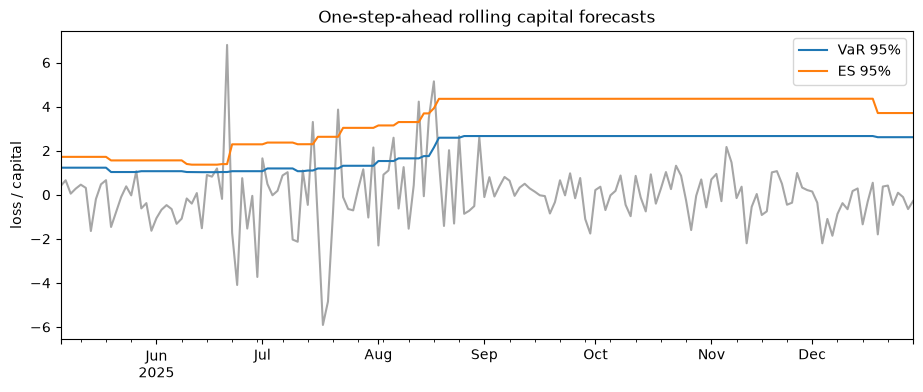

In [8]:
rolling_capital = rolling_risk_estimates(
    loss_data["portfolio"],
    {
        "VaR 95%": ValueAtRiskDistortion(alpha),
        "ES 95%": es_distortion,
    },
    window=128,
    min_periods=128,
)
evaluation_index = loss_data.index[split_position:]

axis = loss_data.loc[evaluation_index, "portfolio"].plot(
    figsize=(11, 4), color="0.65", label="realized loss"
)
rolling_capital.loc[evaluation_index].plot(ax=axis)
axis.set_title("One-step-ahead rolling capital forecasts")
axis.set_ylabel("loss / capital")
plt.show()

## 8. Backtesting and stress evaluation

The capital summary reports frequency and severity of breaches. Kupiec tests whether VaR has the expected unconditional coverage; Christoffersen tests whether its exceedances are independent. These tests diagnose forecast calibration and clustering rather than estimating the risk measure itself.

In [9]:
evaluation_losses = loss_data.loc[evaluation_index, "portfolio"]
evaluation_var = rolling_capital.loc[evaluation_index, "VaR 95%"]
evaluation_es = rolling_capital.loc[evaluation_index, "ES 95%"]

backtest_table = pd.DataFrame(
    {
        "VaR 95%": asdict(capital_backtest(evaluation_losses, evaluation_var)),
        "ES 95%": asdict(capital_backtest(evaluation_losses, evaluation_es)),
    }
)
display(backtest_table)

coverage = kupiec_coverage_test(evaluation_losses, evaluation_var, alpha)
independence = christoffersen_independence_test(evaluation_losses, evaluation_var)
display(
    pd.DataFrame(
        {"Kupiec coverage": asdict(coverage), "Christoffersen independence": asdict(independence)}
    )
)

stress_mask = crisis & (np.arange(n_observations) >= split_position)
stress_result = stress_backtest(
    loss_data["portfolio"],
    rolling_capital["ES 95%"],
    stress_mask,
)
display(pd.Series(asdict(stress_result), name="crisis ES backtest").to_frame())

,VaR 95%,ES 95%
n_observations,170.0000,170.0000
n_exceedances,13.0000,5.0000
exceedance_frequency,0.0765,0.0294
average_capital,2.0216,3.3864
capital_standard_deviation,0.7285,1.1401
mean_absolute_capital_change,0.0131,0.0246
mean_exceedance,1.5945,1.9593
maximum_exceedance,5.7667,5.4070
total_exceedance,20.7287,9.7967


,Kupiec coverage,Christoffersen independence
statistic,2.1735,0.0000
p_value,0.1404,1.0000
degrees_of_freedom,1.0000,1.0000


,crisis ES backtest
n_observations,50.0000
n_exceedances,5.0000
exceedance_frequency,0.1000
average_capital,2.8282
capital_standard_deviation,0.7640
mean_absolute_capital_change,0.0641
mean_exceedance,1.9593
maximum_exceedance,5.4070
total_exceedance,9.7967


## 9. Risk properties, diversification, and sampling uncertainty

Axiom checks are numerical diagnostics on supplied loss vectors. Diversification compares stand-alone and portfolio risk. Finally, block-bootstrap and HAC intervals account for temporal dependence when summarizing the VaR exceedance rate.

In [10]:
es_measure = DistortionRiskMeasure(es_distortion)
comonotonic_a = np.sort(loss_data["asset_a"].iloc[:128].to_numpy())
comonotonic_b = np.sort(loss_data["asset_b"].iloc[:128].to_numpy())
axiom_report = check_risk_measure_axioms(
    es_measure, comonotonic_a, comonotonic_b
)
display(pd.Series(asdict(axiom_report), name="ES diagnostic").to_frame())

benefit = diversification_benefit(
    loss_data["asset_a"].iloc[:256],
    loss_data["asset_b"].iloc[:256],
    es_measure,
)
print("ES diversification benefit:", benefit)

var_exceedances = exceedance_indicator(evaluation_losses, evaluation_var).astype(float)
bootstrap_interval = block_bootstrap_interval(
    var_exceedances,
    block_size=10,
    n_resamples=500,
    random_state=12,
)
hac_result = hac_mean_interval(var_exceedances, max_lags=5)
uncertainty = pd.Series(
    {
        "observed exceedance rate": var_exceedances.mean(),
        "target exceedance rate": 1.0 - alpha,
        "block-bootstrap lower": bootstrap_interval[0],
        "block-bootstrap upper": bootstrap_interval[1],
        "HAC lower": hac_result.lower_bound,
        "HAC upper": hac_result.upper_bound,
    },
    name="estimate",
)
display(uncertainty.to_frame())

,ES diagnostic
monotonicity,True
cash_invariance,True
positive_homogeneity,True
subadditivity,True
convexity,True
comonotonic_additivity,True


ES diversification benefit: 0.5226532820171554


,estimate
observed exceedance rate,0.0765
target exceedance rate,0.0500
block-bootstrap lower,0.0294
block-bootstrap upper,0.1353
HAC lower,0.0314
HAC upper,0.1216


## Workflow summary

1. Express outcomes as losses and keep estimation and evaluation periods chronological.
2. Choose scenario probabilities or a non-additive capacity, then choose a distortion that reflects tail preferences.
3. Estimate VaR, ES, generalized, spectral, or Kusuoka risk and inspect the Choquet contributions.
4. Convert the measure into conditional or rolling capital forecasts without using future observations.
5. Evaluate coverage, independence, stress behavior, diversification, axioms, and sampling uncertainty.